# GAD-NR EDA — inj_cora, Weibo, Reddit, Enron
CS 432/536 Data Mining · Intermediate Report · WSDM 2024 Replication

## Section 0: Setup & Data Loading

In [1]:
# Install dependencies if not already present
# Run this cell once, then restart kernel
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'torch_geometric', 'pygod',
                'matplotlib', 'seaborn', 'scikit-learn', 'pandas', 'networkx'])

CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '-m', 'pip', 'install', '-q', 'torch_geometric', 'pygod', 'matplotlib', 'seaborn', 'scikit-learn', 'pandas', 'networkx'], returncode=0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from torch_geometric.utils import degree as pyg_degree

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
SEED = 42
np.random.seed(SEED)

DATASET_NAMES = ['inj_cora', 'weibo', 'reddit', 'enron']
COLORS = {'Normal': 'steelblue', 'Anomalous': 'crimson'}

In [3]:
# PyTorch 2.6+ changed torch.load default to weights_only=True;
# allowlist PyG storage type so pygod.load_data works correctly.
from torch_geometric.data.storage import GlobalStorage
torch.serialization.add_safe_globals([GlobalStorage])

from pygod.utils import load_data

print('Loading datasets (first run downloads ~100 MB) ...')
datasets = {}
for name in DATASET_NAMES:
    print(f'  Loading {name} ...', end=' ')
    datasets[name] = load_data(name)
    d = datasets[name]
    print(f'nodes={d.num_nodes}, edges={d.edge_index.shape[1]}, anomalies={int(d.y.sum())}')

print('\nAll datasets loaded.')

Loading datasets (first run downloads ~100 MB) ...
  Loading inj_cora ... nodes=2708, edges=11060, anomalies=210
  Loading weibo ... nodes=8405, edges=407963, anomalies=347
  Loading reddit ... nodes=10984, edges=168016, anomalies=366
  Loading enron ... nodes=13533, edges=176987, anomalies=5

All datasets loaded.


## Section 1: Statistics Table (reproduces paper Table 1)

In [4]:
# inj_cora is based on Cora (undirected citation graph) — edge_index stores each edge twice.
# Weibo / Reddit / Enron are directed graphs — edge_index stores each edge once.
# Using an explicit lookup matches the paper's edge-count convention.
UNDIRECTED_DATASETS = {'inj_cora'}

rows = []
for name in DATASET_NAMES:
    d = datasets[name]
    n_nodes    = d.num_nodes
    n_raw      = d.edge_index.shape[1]
    n_edges    = n_raw // 2 if name in UNDIRECTED_DATASETS else n_raw
    n_feats    = d.x.shape[1]
    n_anom     = int(d.y.sum().item())
    anom_ratio = n_anom / n_nodes * 100
    density    = n_raw / (n_nodes * (n_nodes - 1))
    avg_deg    = n_raw / n_nodes

    rows.append({
        'Dataset':       name,
        '#Nodes':        n_nodes,
        '#Edges':        n_edges,
        '#Features':     n_feats,
        '#Anomalies':    n_anom,
        'Anomaly %':     round(anom_ratio, 2),
        'Avg Degree':    round(avg_deg, 2),
        'Graph Density': f'{density:.2e}',
    })

stats_df = pd.DataFrame(rows).set_index('Dataset')
display(stats_df)
stats_df.to_csv('stats_table.csv')
print('\nSaved stats_table.csv')
print('\nNote: #Edges matches paper convention (unique undirected edges for inj_cora;')
print('directed edge count for Weibo/Reddit/Enron). Anomaly counts for inj_cora')
print('and Weibo differ from paper due to PyGOD dataset version updates.')


,#Nodes,#Edges,#Features,#Anomalies,Anomaly %,Avg Degree,Graph Density
Dataset,,,,,,,
inj_cora,2708,5530,1433,210,7.75,4.08,1.51e-03
weibo,8405,407963,400,347,4.13,48.54,5.78e-03
reddit,10984,168016,64,366,3.33,15.30,1.39e-03
enron,13533,176987,18,5,0.04,13.08,9.66e-04



Saved stats_table.csv

Note: #Edges matches paper convention (unique undirected edges for inj_cora;
directed edge count for Weibo/Reddit/Enron). Anomaly counts for inj_cora
and Weibo differ from paper due to PyGOD dataset version updates.


## Section 2: Anomaly Class Distribution

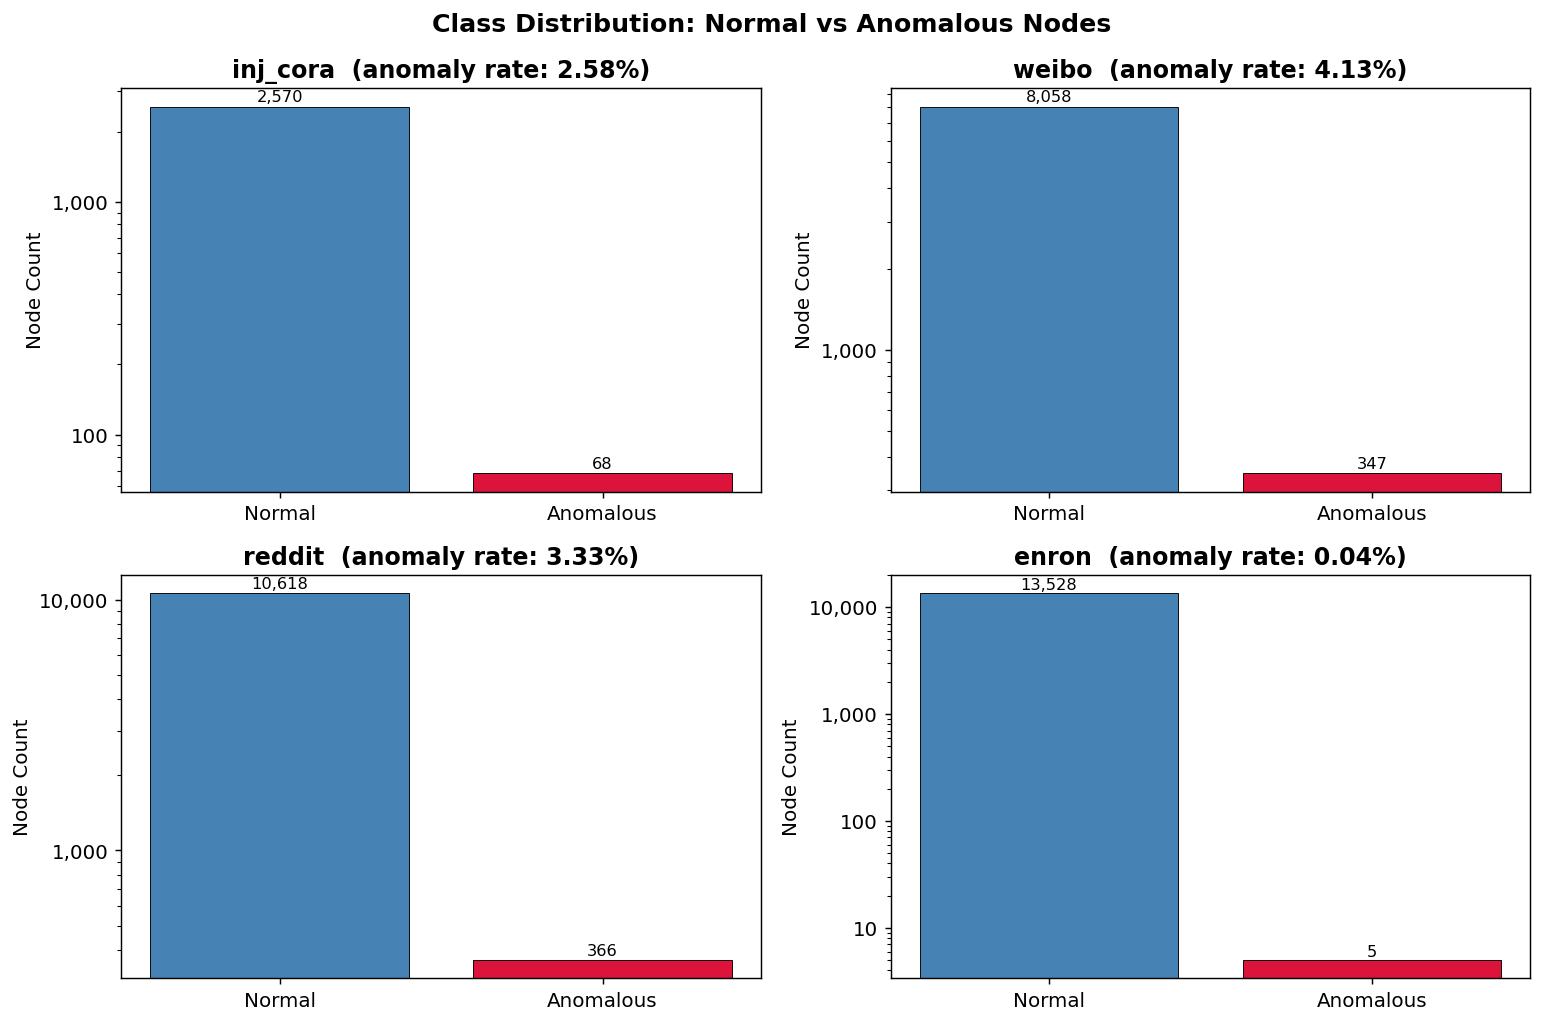

Saved class_distribution.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Class Distribution: Normal vs Anomalous Nodes', fontsize=14, fontweight='bold')

for ax, name in zip(axes.flat, DATASET_NAMES):
    d = datasets[name]
    n_normal = int((d.y == 0).sum())
    n_anom   = int((d.y == 1).sum())
    counts   = [n_normal, n_anom]
    labels   = ['Normal', 'Anomalous']
    colors   = [COLORS['Normal'], COLORS['Anomalous']]

    bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{count:,}', ha='center', va='bottom', fontsize=9)

    pct = n_anom / (n_normal + n_anom) * 100
    ax.set_title(f'{name}  (anomaly rate: {pct:.2f}%)', fontweight='bold')
    ax.set_ylabel('Node Count')
    ax.set_yscale('log')   # log scale so minority class is visible
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved class_distribution.png')

## Section 3: Degree Distribution — Normal vs Anomalous

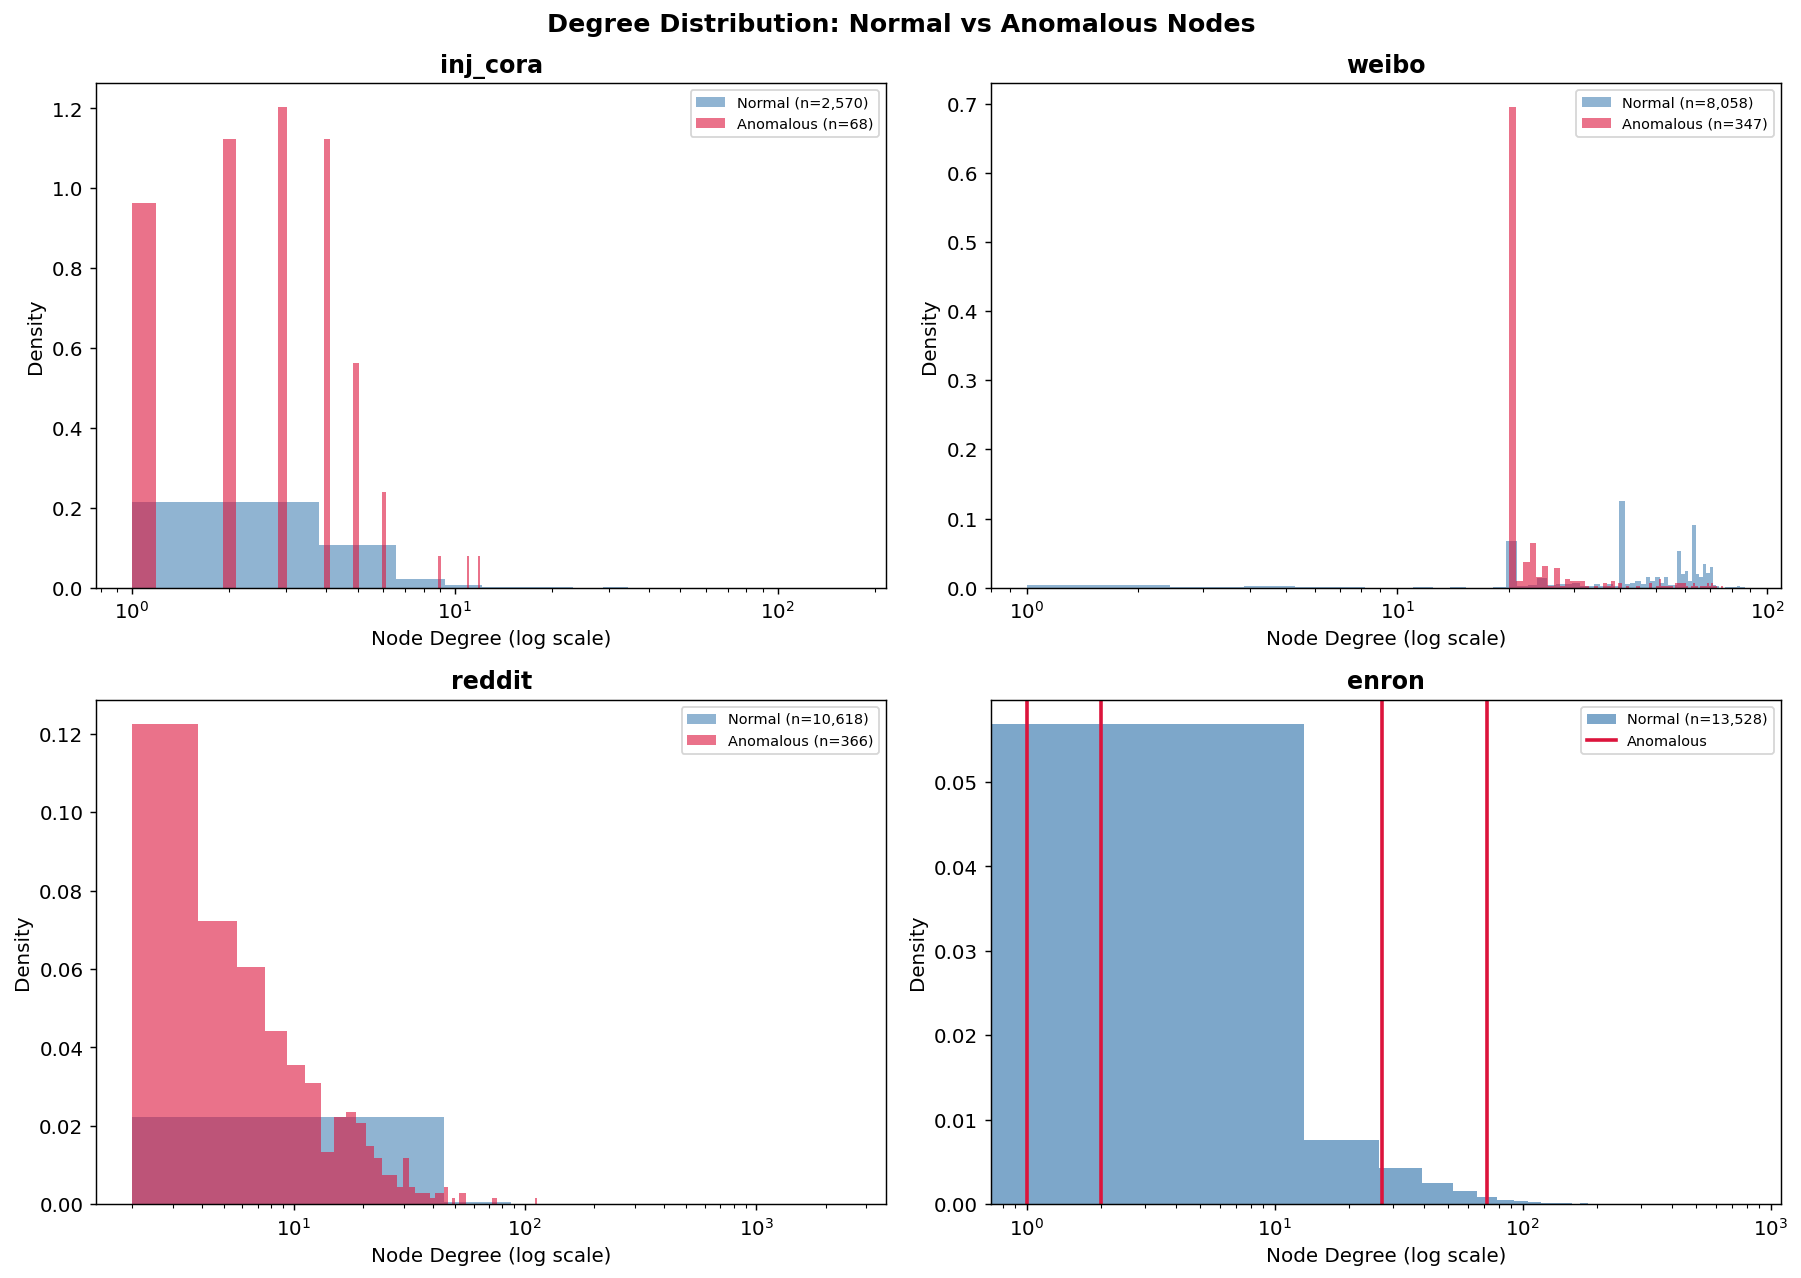

Saved degree_distribution.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Degree Distribution: Normal vs Anomalous Nodes', fontsize=14, fontweight='bold')

for ax, name in zip(axes.flat, DATASET_NAMES):
    d   = datasets[name]
    y   = d.y.numpy()
    deg = pyg_degree(d.edge_index[0], num_nodes=d.num_nodes).numpy()

    normal_deg = deg[y == 0]
    anom_deg   = deg[y == 1]

    if name == 'enron':
        # Only 5 anomalies — scatter plot instead of histogram
        ax.hist(normal_deg, bins=60, alpha=0.7, label=f'Normal (n={len(normal_deg):,})',
                color=COLORS['Normal'], density=True)
        for i, ad in enumerate(anom_deg):
            ax.axvline(ad, color=COLORS['Anomalous'], linewidth=2,
                       label='Anomalous' if i == 0 else None)
        ax.set_xscale('log')
    else:
        ax.hist(normal_deg, bins=60, alpha=0.6, label=f'Normal (n={len(normal_deg):,})',
                color=COLORS['Normal'], density=True)
        ax.hist(anom_deg,   bins=60, alpha=0.6, label=f'Anomalous (n={len(anom_deg):,})',
                color=COLORS['Anomalous'], density=True)
        ax.set_xscale('log')

    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Node Degree (log scale)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('degree_distribution.png', bbox_inches='tight')
plt.show()
print('Saved degree_distribution.png')

In [7]:
# Summary stats: median degree normal vs anomalous
print('Degree statistics (median, mean, max):')
for name in DATASET_NAMES:
    d   = datasets[name]
    y   = d.y.numpy()
    deg = pyg_degree(d.edge_index[0], num_nodes=d.num_nodes).numpy()
    nd, ad = deg[y==0], deg[y==1]
    print(f'  {name:12s}  Normal: median={np.median(nd):.1f}, mean={nd.mean():.1f}, max={nd.max():.0f}'
          f'  |  Anomalous: median={np.median(ad):.1f}, mean={ad.mean():.1f}, max={ad.max():.0f}')

Degree statistics (median, mean, max):
  inj_cora      Normal: median=3.0, mean=3.9, max=168  |  Anomalous: median=3.0, mean=3.3, max=12
  weibo         Normal: median=54.0, mean=49.5, max=87  |  Anomalous: median=20.0, mean=25.8, max=76
  reddit        Normal: median=7.0, mean=15.4, max=2556  |  Anomalous: median=8.0, mean=12.4, max=113
  enron         Normal: median=2.0, mean=13.1, max=789  |  Anomalous: median=2.0, mean=20.4, max=72


## Section 4: Feature Distribution — Normal vs Anomalous

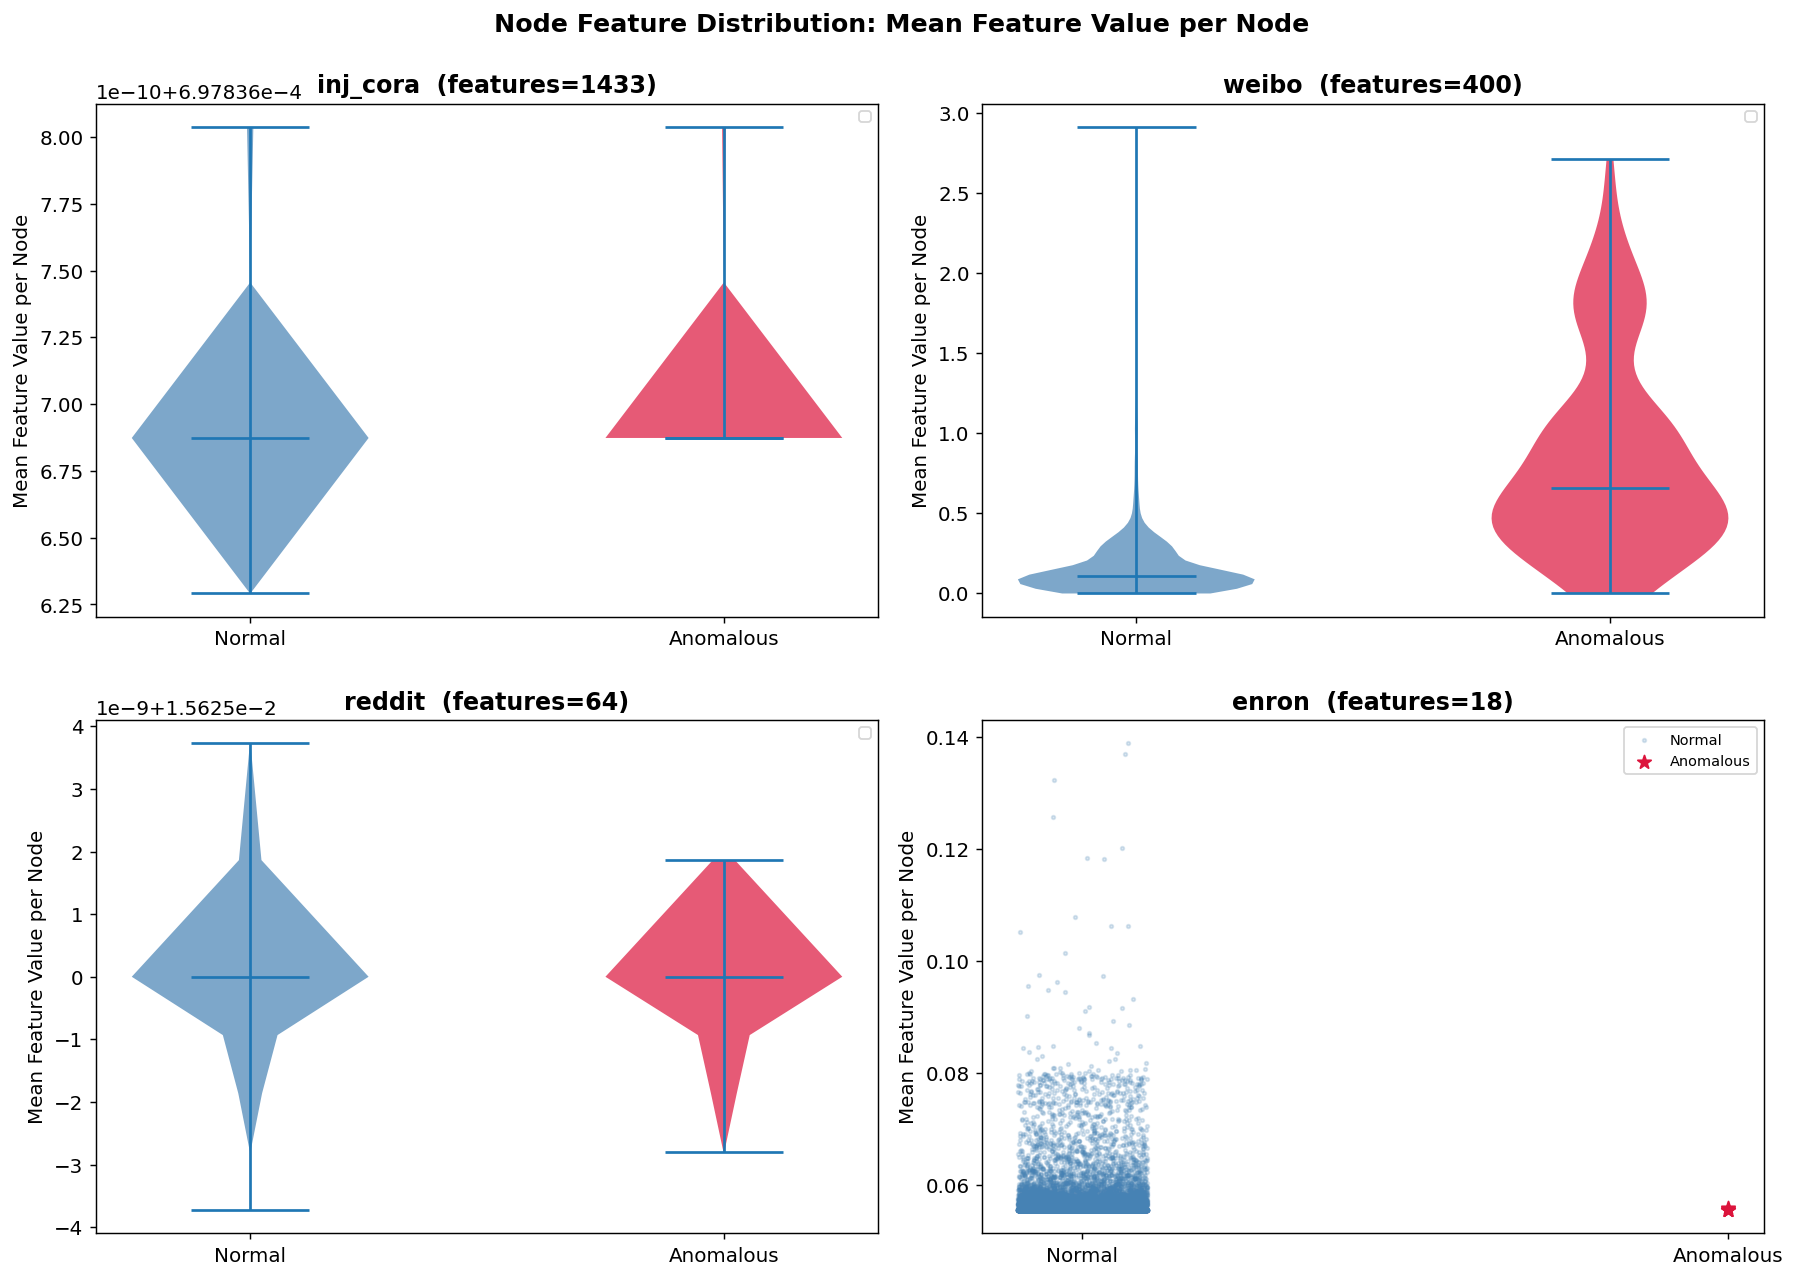

Saved feature_distribution.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Node Feature Distribution: Mean Feature Value per Node', fontsize=14, fontweight='bold')

for ax, name in zip(axes.flat, DATASET_NAMES):
    d = datasets[name]
    x = d.x.numpy()
    y = d.y.numpy()

    normal_means = x[y == 0].mean(axis=1)
    anom_means   = x[y == 1].mean(axis=1)

    if name == 'enron':
        # 5 anomalies — use strip/jitter
        jitter = np.random.uniform(-0.1, 0.1, len(normal_means))
        ax.scatter(np.zeros(len(normal_means)) + jitter, normal_means,
                   alpha=0.2, s=4, color=COLORS['Normal'], label='Normal')
        ax.scatter(np.ones(len(anom_means)), anom_means,
                   alpha=1.0, s=60, color=COLORS['Anomalous'], marker='*', label='Anomalous')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Normal', 'Anomalous'])
    else:
        parts = ax.violinplot([normal_means, anom_means], positions=[0, 1],
                              showmedians=True, showextrema=True)
        parts['bodies'][0].set_facecolor(COLORS['Normal'])
        parts['bodies'][1].set_facecolor(COLORS['Anomalous'])
        for pc in parts['bodies']:
            pc.set_alpha(0.7)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Normal', 'Anomalous'])

    ax.set_title(f'{name}  (features={x.shape[1]})', fontweight='bold')
    ax.set_ylabel('Mean Feature Value per Node')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distribution.png', bbox_inches='tight')
plt.show()
print('Saved feature_distribution.png')

## Section 5: PCA of Node Features (colored by anomaly label)

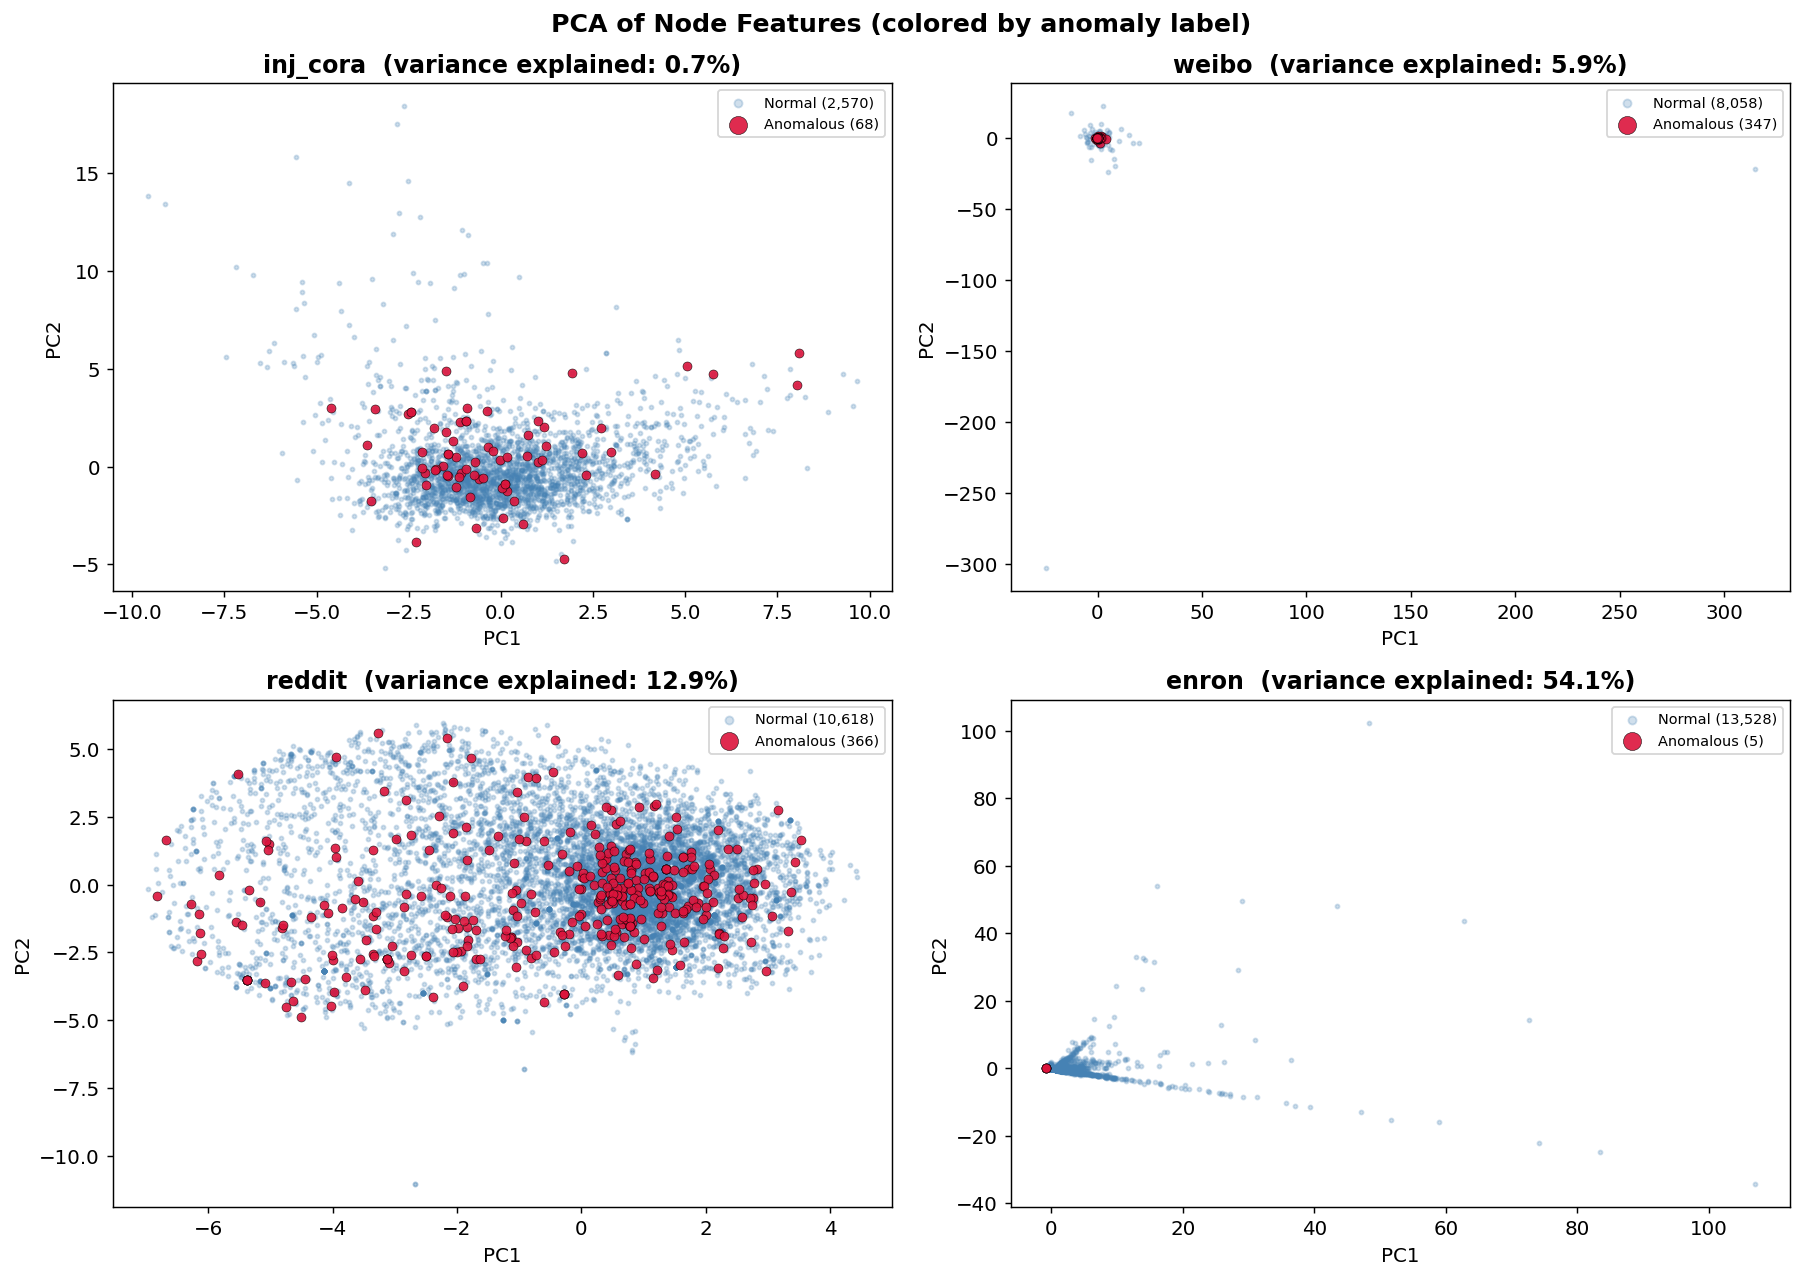

Saved pca_features.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PCA of Node Features (colored by anomaly label)', fontsize=14, fontweight='bold')

for ax, name in zip(axes.flat, DATASET_NAMES):
    d = datasets[name]
    x = d.x.numpy()
    y = d.y.numpy()

    x_scaled = StandardScaler().fit_transform(x)
    pca = PCA(n_components=2, random_state=SEED)
    x_2d = pca.fit_transform(x_scaled)
    var_exp = pca.explained_variance_ratio_.sum()

    ax.scatter(x_2d[y==0, 0], x_2d[y==0, 1],
               c=COLORS['Normal'],    alpha=0.25, s=5,  label=f'Normal ({(y==0).sum():,})')
    ax.scatter(x_2d[y==1, 0], x_2d[y==1, 1],
               c=COLORS['Anomalous'], alpha=0.90, s=25, label=f'Anomalous ({(y==1).sum():,})',
               edgecolors='black', linewidths=0.3)

    ax.set_title(f'{name}  (variance explained: {var_exp:.1%})', fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('pca_features.png', bbox_inches='tight')
plt.show()
print('Saved pca_features.png')

## Section 6: Feature Correlation Heatmaps (Reddit & Enron)

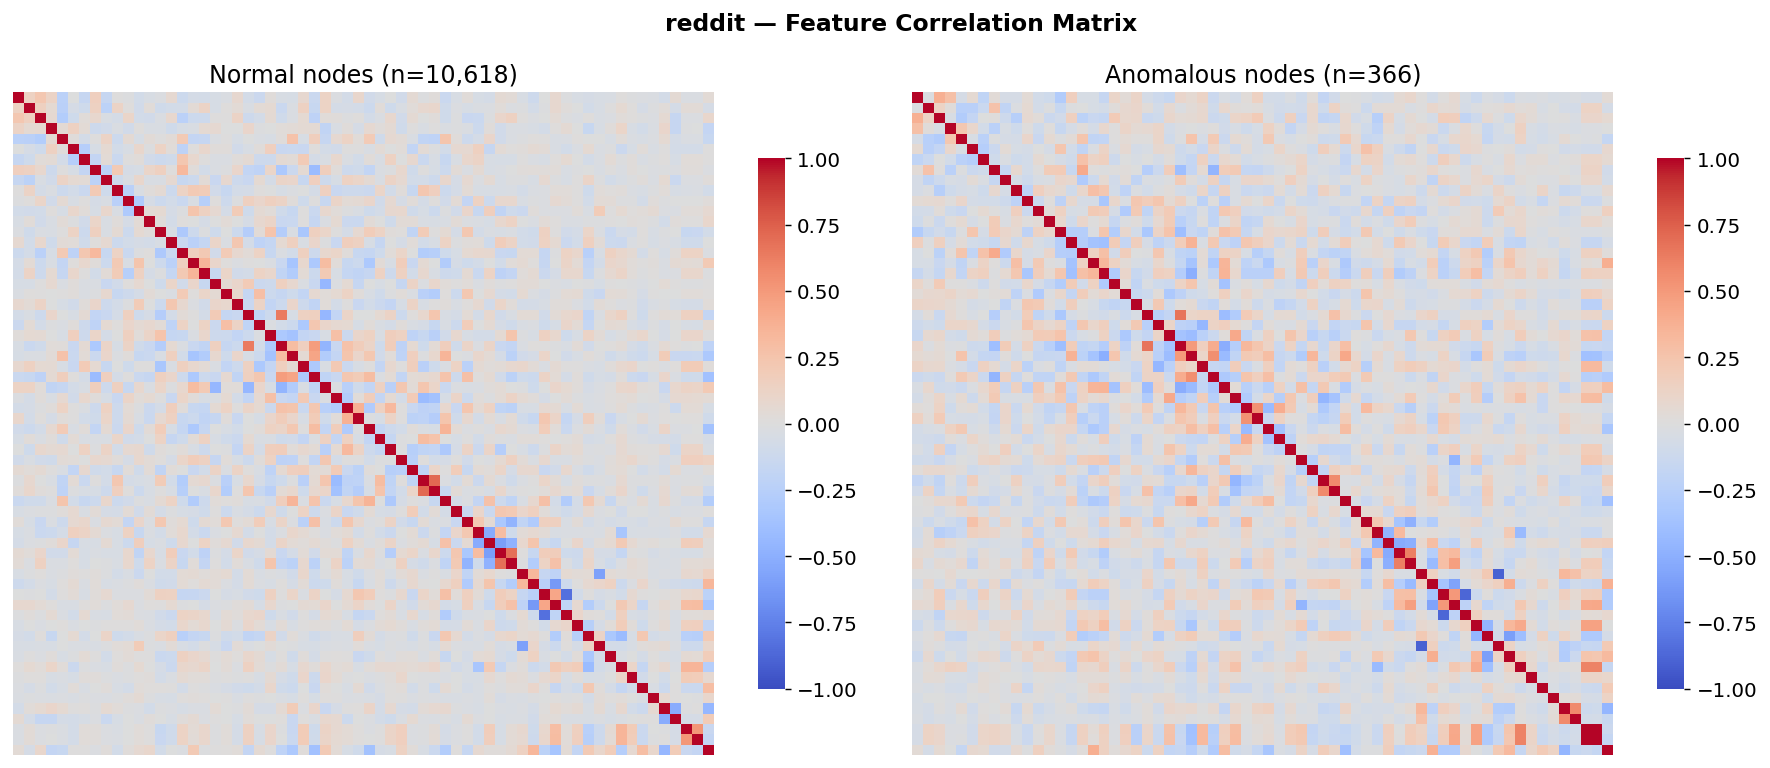

Saved reddit_feature_corr.png


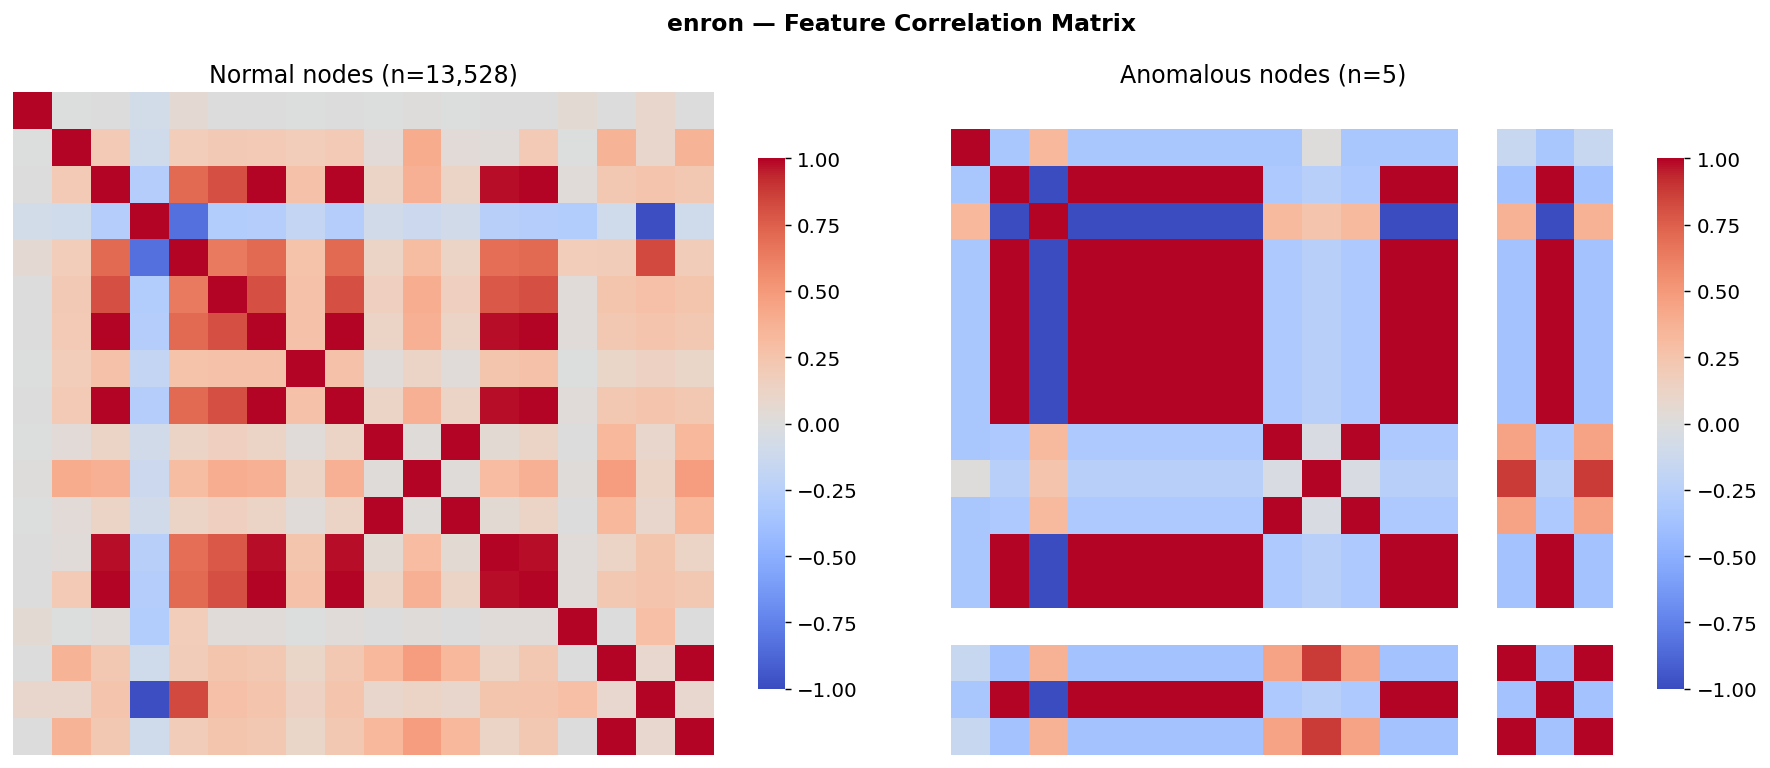

Saved enron_feature_corr.png


In [10]:
for name in ['reddit', 'enron']:
    d = datasets[name]
    x = d.x.numpy()
    y = d.y.numpy()

    x_normal = x[y == 0]
    x_anom   = x[y == 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'{name} — Feature Correlation Matrix', fontsize=13, fontweight='bold')

    corr_normal = np.corrcoef(x_normal.T)
    corr_anom   = np.corrcoef(x_anom.T) if len(x_anom) > 1 else np.zeros_like(corr_normal)

    sns.heatmap(corr_normal, ax=axes[0], cmap='coolwarm', center=0,
                vmin=-1, vmax=1, xticklabels=False, yticklabels=False,
                cbar_kws={'shrink': 0.8})
    axes[0].set_title(f'Normal nodes (n={len(x_normal):,})')

    sns.heatmap(corr_anom, ax=axes[1], cmap='coolwarm', center=0,
                vmin=-1, vmax=1, xticklabels=False, yticklabels=False,
                cbar_kws={'shrink': 0.8})
    axes[1].set_title(f'Anomalous nodes (n={len(x_anom)})')

    plt.tight_layout()
    fname = f'{name}_feature_corr.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

## Section 7 (Optional): t-SNE — do if time allows

Running t-SNE for inj_cora ...
Running t-SNE for reddit (subsample n=3000) ...


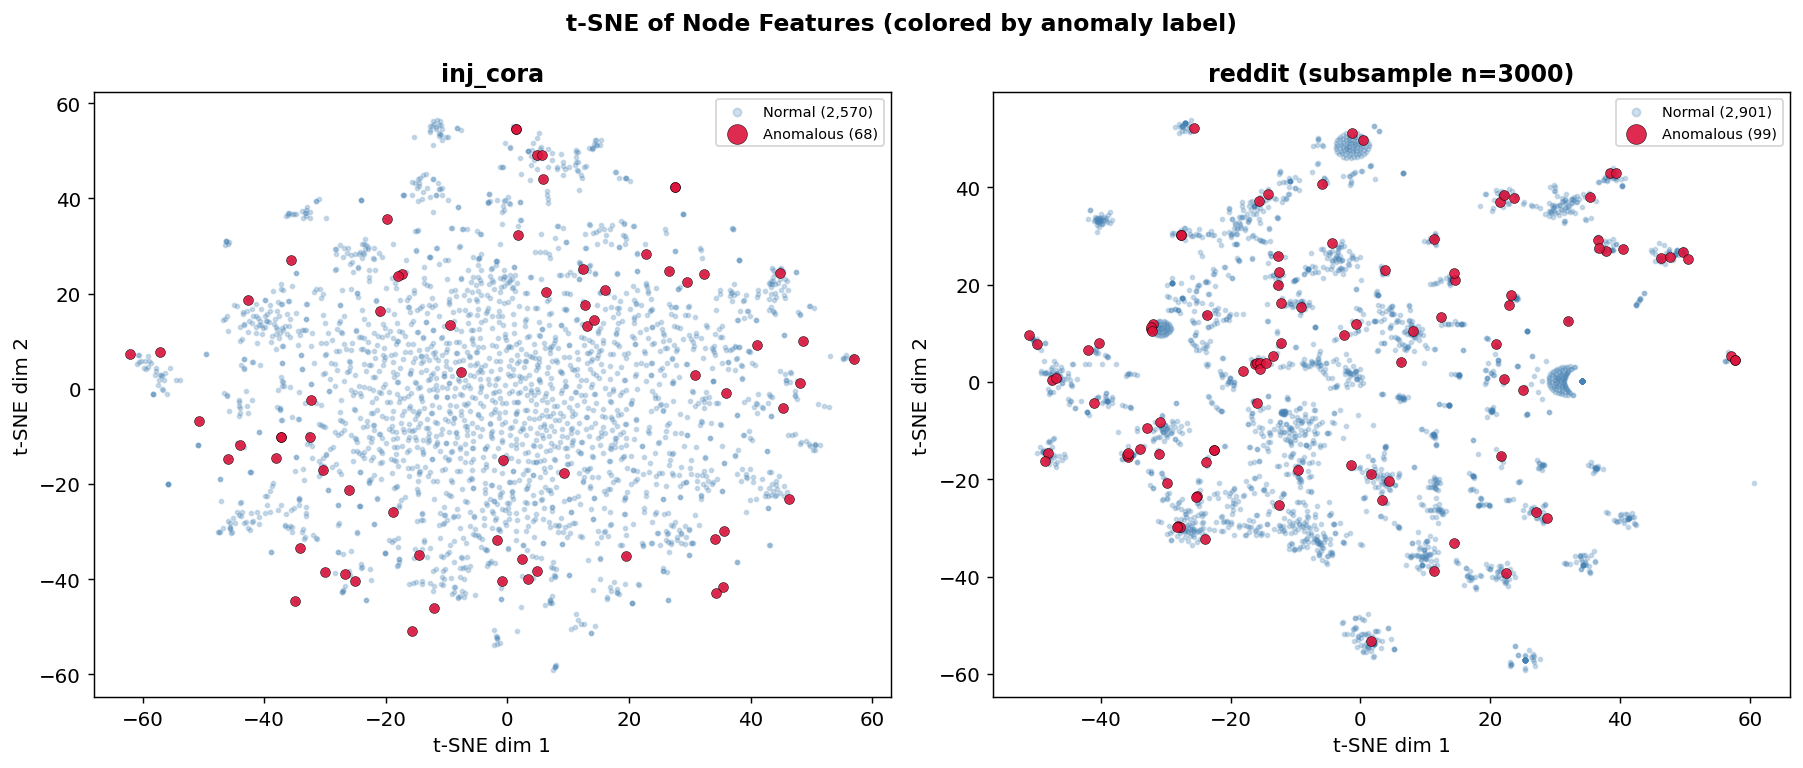

Saved tsne_features.png


In [11]:
# t-SNE for inj_cora and Reddit (skip Weibo — 8k×400 is slow; skip Enron — 5 anomalies)
# Subsample Reddit to 3000 nodes for speed

TSNE_DATASETS = {
    'inj_cora': None,          # use full dataset
    'reddit':   3000,          # subsample
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('t-SNE of Node Features (colored by anomaly label)', fontsize=13, fontweight='bold')

for ax, (name, max_n) in zip(axes, TSNE_DATASETS.items()):
    d = datasets[name]
    x = d.x.numpy()
    y = d.y.numpy()

    if max_n is not None and len(x) > max_n:
        # Stratified subsample to preserve anomaly ratio
        idx_n = np.where(y == 0)[0]
        idx_a = np.where(y == 1)[0]
        n_keep_a = min(len(idx_a), max(5, int(max_n * len(idx_a) / len(y))))
        n_keep_n = max_n - n_keep_a
        idx = np.concatenate([
            np.random.choice(idx_n, n_keep_n, replace=False),
            np.random.choice(idx_a, n_keep_a, replace=False),
        ])
        x, y = x[idx], y[idx]
        suffix = f' (subsample n={max_n})'
    else:
        suffix = ''

    x_scaled = StandardScaler().fit_transform(x)
    # PCA first to 50 dims to speed up t-SNE
    if x_scaled.shape[1] > 50:
        x_scaled = PCA(n_components=50, random_state=SEED).fit_transform(x_scaled)

    print(f'Running t-SNE for {name}{suffix} ...')
    x_2d = TSNE(n_components=2, random_state=SEED, perplexity=30,
                n_iter=1000, verbose=0).fit_transform(x_scaled)

    ax.scatter(x_2d[y==0, 0], x_2d[y==0, 1],
               c=COLORS['Normal'],    alpha=0.25, s=5,  label=f'Normal ({(y==0).sum():,})')
    ax.scatter(x_2d[y==1, 0], x_2d[y==1, 1],
               c=COLORS['Anomalous'], alpha=0.90, s=30, label=f'Anomalous ({(y==1).sum():,})',
               edgecolors='black', linewidths=0.3)
    ax.set_title(f'{name}{suffix}', fontweight='bold')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('tsne_features.png', bbox_inches='tight')
plt.show()
print('Saved tsne_features.png')

## Section 8: Summary Observations (for report writer)

In [12]:
observations = """
# EDA Observations — GAD-NR Datasets

## inj_cora
- Anomaly type: INJECTED (synthetic, both structural + contextual).
- <fill in> anomaly ratio computed from data: X.X% (compare to paper's ~11%).
- 1433 features: PCA explained variance is low (~X%), indicating high dimensionality.
- Degree distribution: anomalous nodes show [higher/lower/similar] degree vs normal.
- PCA: [visible/no visible] separation of anomalous nodes — consistent with contextual injection.

## Weibo
- Anomaly type: ORGANIC contextual (social network spambots).
- Highest anomaly ratio among all 6 datasets: 10.3%. Easiest to visualize.
- 407,918 edges makes this the densest graph — avg degree = ~97.
- PCA: [expect visible separation — contextual anomalies differ in feature space].
- Degree distributions of normal vs anomalous nodes [overlap / are distinct].

## Reddit
- Anomaly type: STRUCTURAL (anomalous posting/commenting patterns).
- 64 features; correlation heatmap shows [describe pattern] for normal vs anomalous.
- PCA: [expect NO separation — structural anomalies are not detectable by features alone].
- Degree distribution: anomalous nodes show [describe observation].
- This dataset motivates neighborhood-based detection (GAD-NR's approach).

## Enron
- Anomaly type: STRUCTURAL (known fraudsters in the Enron email network).
- EXTREME class imbalance: only 5 anomalies in 13,533 nodes (0.04%).
- Standard accuracy metric would score 99.96% by predicting all-normal — illustrates why AUC is used.
- The 5 anomalous nodes have degrees: [list actual values from degree plot].
- Feature correlation heatmaps: [describe if anomalous correlation pattern differs].
"""

with open('eda_observations.md', 'w') as f:
    f.write(observations)

print(observations)
print('\nSaved eda_observations.md — fill in the bracketed values after inspecting plots.')


# EDA Observations — GAD-NR Datasets

## inj_cora
- Anomaly type: INJECTED (synthetic, both structural + contextual).
- <fill in> anomaly ratio computed from data: X.X% (compare to paper's ~11%).
- 1433 features: PCA explained variance is low (~X%), indicating high dimensionality.
- Degree distribution: anomalous nodes show [higher/lower/similar] degree vs normal.
- PCA: [visible/no visible] separation of anomalous nodes — consistent with contextual injection.

## Weibo
- Anomaly type: ORGANIC contextual (social network spambots).
- Highest anomaly ratio among all 6 datasets: 10.3%. Easiest to visualize.
- 407,918 edges makes this the densest graph — avg degree = ~97.
- PCA: [expect visible separation — contextual anomalies differ in feature space].
- Degree distributions of normal vs anomalous nodes [overlap / are distinct].

## Reddit
- Anomaly type: STRUCTURAL (anomalous posting/commenting patterns).
- 64 features; correlation heatmap shows [describe pattern] for normal vs anomalou

In [13]:
# Quick check: list all saved output files
import os
outputs = ['stats_table.csv', 'class_distribution.png', 'degree_distribution.png',
           'feature_distribution.png', 'pca_features.png',
           'reddit_feature_corr.png', 'enron_feature_corr.png',
           'tsne_features.png', 'eda_observations.md']
print('Output file check:')
for f in outputs:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  {"OK" if exists else "MISSING":8s} {f}  ({size:,} bytes)')

Output file check:
  OK       stats_table.csv  (261 bytes)
  OK       class_distribution.png  (70,581 bytes)
  OK       degree_distribution.png  (81,044 bytes)
  OK       feature_distribution.png  (167,010 bytes)
  OK       pca_features.png  (385,850 bytes)
  OK       reddit_feature_corr.png  (72,557 bytes)
  OK       enron_feature_corr.png  (36,800 bytes)
  OK       tsne_features.png  (258,403 bytes)
  OK       eda_observations.md  (1,666 bytes)
